<a href="https://colab.research.google.com/github/kasulavenkatabalaji/mlproject/blob/main/titanicEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


inspecting the data


In [48]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


replacing 0 and 1 with yes or no in survival column


In [49]:
df['Survived'] = df['Survived'].astype(int)
df['Survived'] = df['Survived'].replace("yes", 1)
df['Survived'] = df['Survived'].replace("no", 0)

df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


checking null values

In [50]:
missing=df.isnull().sum()
missing_pct=(df.isnull().sum()/len(df)*100).round(2)

missing_df=pd.DataFrame({
    'missing':missing,
    'missing_pct':missing_pct
})
print(missing_df[missing_df['missing'] >0])

          missing  missing_pct
Age           177        19.87
Cabin         687        77.10
Embarked        2         0.22


handling missing values

In [51]:
df['Age']=df["Age"].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop('Cabin' , axis =1 , inplace=True )
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


statistics of the data

In [52]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


checking duplicate values

In [53]:
df.duplicated().sum()
df['Ticket'].duplicated().sum()

np.int64(210)

count how many survived by countplot

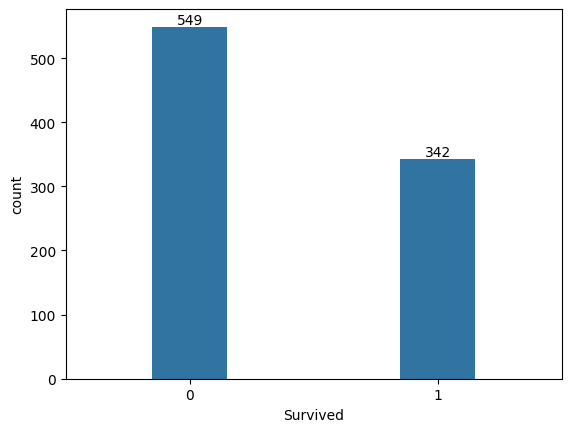

In [54]:
ax=sns.countplot(x = df['Survived'], width=0.30 )
ax.bar_label(ax.containers[0])
plt.show()

In percentage

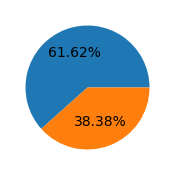

In [55]:
gb =df.groupby('Survived').agg({'Survived': 'count'})
plt.figure(figsize=(2,5))
plt.pie(gb['Survived'] , autopct='%1.2f%%')
plt.show()

survival rate by gender (bar chart)

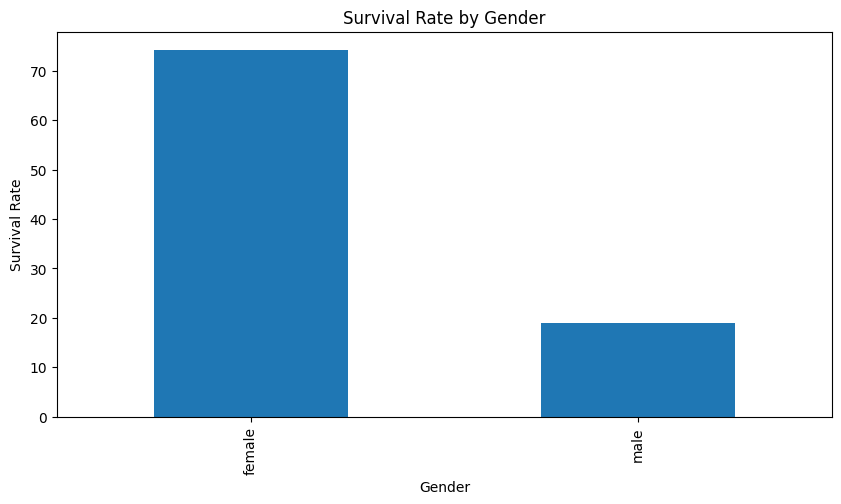

In [56]:
fig,axes=plt.subplots( figsize=(10,5))

survival_rate=df.groupby('Sex')['Survived'].mean()*100
survival_rate.plot(kind='bar', ax=axes)
axes.set_xlabel('Gender')
axes.set_ylabel('Survival Rate')
axes.set_title('Survival Rate by Gender')
plt.show()

survival rate by passenger class (bar chart)

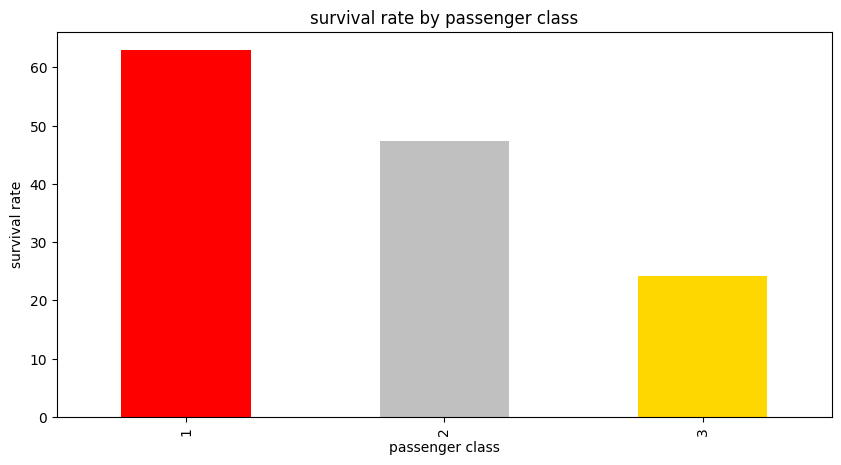

In [57]:
fig,axes=plt.subplots( figsize=(10,5))

survival_rate=df.groupby('Pclass')['Survived'].mean()*100
survival_rate.plot(kind='bar', ax=axes, color={'gold','silver','red'})

axes.set_xlabel('passenger class')
axes.set_ylabel('survival rate')
axes.set_title('survival rate by passenger class')
plt.show()


age distribution (histogram)

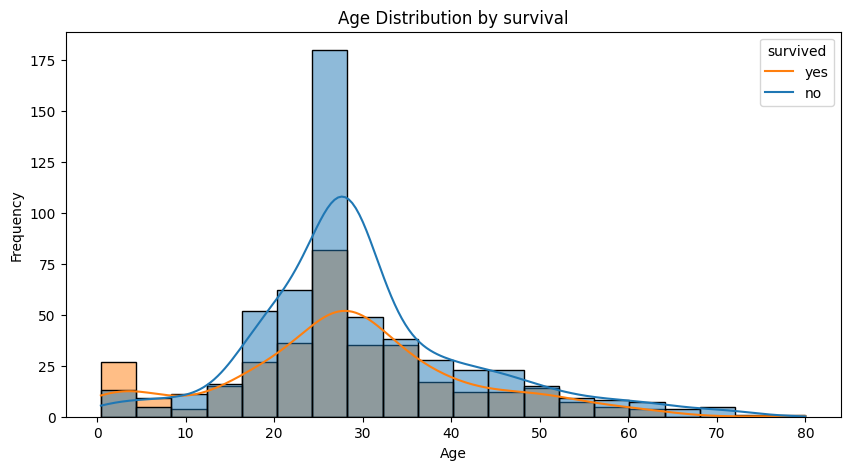

In [58]:
plt.figure(figsize=(10,5))
sns.histplot(x=df['Age'], hue=df['Survived'] ,kde=True, bins=20 , color='steelblue')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by survival')
plt.legend(title='survived',labels=['yes','no'])
plt.show()

note: the spike between 25-30 is caused by filling the missing values of age through median which is unnatural

correlation heat map


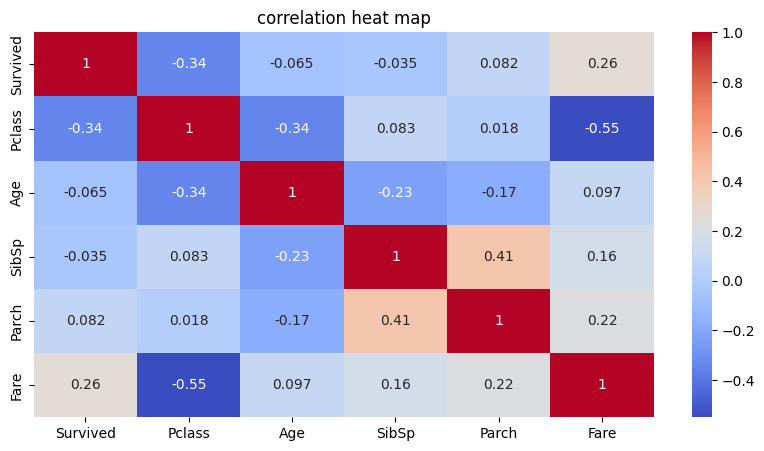

In [62]:
correlation=df.drop('PassengerId', axis=1).corr(numeric_only=True)
plt.figure(figsize=(10,5))
sns.heatmap(correlation, annot=True , cmap='coolwarm')
plt.title('correlation heat map')
plt.show()

## Key Insights

**1. Gender was the strongest predictor of survival.**
Women survived at a rate of 74.2% compared to just 18.9% for men — a gap of over 55 percentage points. This single factor outweighs almost every other variable in the dataset, strongly reflecting the "women and children first" evacuation protocol.

**2. Passenger class had a major impact on survival, driven largely by access and fare.**
1st class passengers survived at 62.9%, while 3rd class passengers survived at only 24.2% — more than 2x the difference. This is reinforced by the correlation heatmap, which shows a strong negative relationship between Pclass and Fare (-0.55), meaning 1st class tickets were significantly more expensive and likely came with better access to lifeboats and upper decks.

**3. Younger passengers had a slightly higher chance of survival.**
The age distribution split by survival shows children and younger passengers skewed toward the "survived" group more than older adults did, consistent with the same evacuation priority seen in the gender breakdown. However, age alone is a weak predictor (correlation with Survived was only -0.08), suggesting it mattered more in combination with other factors like class and gender.

**4. No single factor fully explains survival — it was a combination of class, fare, and gender.**
The correlation heatmap shows that no variable correlates with Survived above ±0.35 except Pclass. This tells us survival wasn't determined by one dominant factor; rather, it emerged from overlapping circumstances — being female, traveling in 1st class, and paying a higher fare all independently increased the odds.

**5. Data quality required careful handling, particularly with missing values.**
Age had 177 missing values (19.9%) and was imputed using the median (28 years) rather than the mean, since median is more robust to outliers. Cabin had 687 missing values (77.1%) and was dropped entirely rather than imputed, since fabricating data for over three-quarters of a column would have introduced more noise than signal. It's worth noting that the median imputation for Age does create a visible artificial spike around 25-30 years in the age distribution chart, which should be considered when interpreting that specific visualization.